# X-Ray Shapley: Data Valuation Pipeline

**Purpose**: End-to-end pipeline for data valuation of NIH Chest X-rays using SHAP and Shapley values.

**Dataset**: Using 5% sample (~2.3 GB, ~5,606 images). To use full dataset (45 GB, 112,120 images), modify Section 1.1 (download cell).

**Workflow**:
1. Download NIH Chest X-rays dataset from Kaggle
2. Extract embeddings using pretrained ResNet50
3. Train XGBoost classifier on extracted features
4. Compute feature-level SHAP values
5. Compute data-level Shapley values for sample valuation

**Core Research Question**: Which training samples contribute most to model quality?

## Setup: Import All Dependencies

In [ ]:
# Standard libraries
import os
import pickle
import shutil
from pathlib import Path

# Dataset download
import kagglehub

# Visualization
import matplotlib.pyplot as plt

# Data handling
import numpy as np
import pandas as pd
import seaborn as sns

# Explainability
import shap

# ML and feature extraction
import torch
import torchvision.models as models

# Modeling
import xgboost as xgb
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

---

# Section 1: Data Download and Preparation

## 1.1: Download NIH Chest X-rays Dataset from Kaggle

In [2]:
# Note: Ensure Kaggle API credentials are set up
# Instructions: https://github.com/Kaggle/kaggle-api#api-credentials

# Using 5% sample dataset (~2.3 GB) instead of full dataset (45 GB)
# Change to "nih-chest-xrays/data" to download full dataset (larger, more samples)
print("Downloading NIH Chest X-rays 5% sample dataset from Kaggle...")
print("(This is ~2.3 GB. Full dataset is ~45 GB - use 'nih-chest-xrays/data' if you want the full version)")
kaggle_path = kagglehub.dataset_download("nih-chest-xrays/sample")
print(f"Downloaded to: {kaggle_path}")

(This is ~2.3 GB. Full dataset is ~45 GB - use 'nih-chest-xrays/data' if you want the full version)
Downloaded to: /Users/jaidensiu/.cache/kagglehub/datasets/nih-chest-xrays/sample/versions/4


## 1.2: Organize Data into Local Directory

In [3]:
# Create target directory
target_dir = Path("./data")
target_dir.mkdir(parents=True, exist_ok=True)

# Copy dataset files
print(f"Copying files to {target_dir}...")
for item in os.listdir(kaggle_path):
    src = os.path.join(kaggle_path, item)
    dst = target_dir / item

    if os.path.isdir(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print("Dataset organized successfully")

Copying files to data...
Dataset organized successfully


## 1.3: Exploratory Data Analysis

In [4]:
# Display dataset structure
print("Dataset structure:")
data_raw_dir = Path("./data")
for root, dirs, files in os.walk(data_raw_dir):
    level = root.replace(str(data_raw_dir), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files) - 5} more files")

Dataset structure:
data/
  sample_labels.csv
  sample/
    sample_labels.csv
    images/
      00018805_001.png
      00011723_001.png
      00025380_000.png
      00008211_000.png
      00003459_017.png
      ... and 5601 more files
    sample/
      images/
        00018805_001.png
        00011723_001.png
        00025380_000.png
        00008211_000.png
        00003459_017.png
        ... and 5601 more files


---

# Section 2: Feature Extraction with Pretrained CNN

## 2.1: Load Pretrained ResNet50

In [5]:
# Load pretrained ResNet50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Remove final classification layer to get embeddings
model = torch.nn.Sequential(*list(model.children())[:-1])  # 2048-dim embeddings
model.to(device)
model.eval()

print(f"Model loaded on {device}")
print("Output dimension: 2048")

Model loaded on cpu
Output dimension: 2048


## 2.2: Define Data Transform and Custom Dataset

In [6]:
# ImageNet preprocessing
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class XRayDataset(Dataset):
    """Custom dataset for loading X-ray images."""

    def __init__(self, image_dir, transform=None, label=None):
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.label = label

        # Find all image files
        self.image_files = list(self.image_dir.glob("*.png")) + list(self.image_dir.glob("*.jpg"))
        print(f"Found {len(self.image_files)} images in {image_dir}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path.name, self.label


print("Dataset class defined")

Dataset class defined


## 2.3: Feature Extraction Function

In [7]:
def extract_features(dataset, model, device, batch_size=32):
    """Extract features for all images in a dataset."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    all_features = []
    all_labels = []

    with torch.no_grad():
        for batch_images, file_names, labels in tqdm(loader, desc="Extracting features"):
            batch_images = batch_images.to(device)

            # Forward pass through ResNet50 (without classification layer)
            embeddings = model(batch_images)
            embeddings = embeddings.squeeze(-1).squeeze(-1)  # Remove spatial dimensions

            all_features.append(embeddings.cpu().numpy())

            # Collect per-sample labels
            for label in labels:
                if label is not None:
                    all_labels.append(label.item() if isinstance(label, torch.Tensor) else label)

    features = np.vstack(all_features)
    labels = np.array(all_labels) if all_labels else None

    return features, labels


print("Feature extraction function defined")

Feature extraction function defined


## 2.4: Extract and Cache Features

In [ ]:
data_features_dir = Path("./embeddings")
data_features_dir.mkdir(parents=True, exist_ok=True)
data_raw_dir = Path("./data")

print(f"Raw data directory: {data_raw_dir}")
print(f"Features directory: {data_features_dir}")

# Load labels from CSV
labels_csv = data_raw_dir / "sample_labels.csv"
if not labels_csv.exists():
    print(f"✗ Labels file not found: {labels_csv}")
    raise FileNotFoundError(f"Expected {labels_csv}")

print(f"✓ Found {labels_csv.name}")
df_labels = pd.read_csv(labels_csv)
print(f"  Loaded {len(df_labels)} rows")
print(f"  Columns: {df_labels.columns.tolist()}")
print("\nFirst few rows:")
print(df_labels.head())

# Images are in sample/images subdirectory
image_dir = data_raw_dir / "sample" / "images"
if not image_dir.exists():
    print(f"\n✗ Image directory not found: {image_dir}")
    raise FileNotFoundError(f"Expected {image_dir}")

image_files = sorted(list(image_dir.glob("*.png")) + list(image_dir.glob("*.jpg")))
print(f"\n✓ Found {len(image_files)} images in {image_dir.name}/")

print("\n" + "=" * 50)
print("CREATING DATASET")
print("=" * 50)


class XRayDatasetWithLabels(Dataset):
    """Dataset that loads images and labels from CSV."""

    def __init__(self, image_dir, labels_df, transform=None):
        self.image_dir = Path(image_dir)
        self.transform = transform

        # Find all image files
        self.image_files = sorted(list(self.image_dir.glob("*.png")) + list(self.image_dir.glob("*.jpg")))
        print(f"Found {len(self.image_files)} image files")

        # Map filenames to binary labels (No Finding vs Any Finding)
        self.valid_images = []

        # Use 'Image Index' column for filename and 'Finding Labels' for disease labels
        for idx, row in labels_df.iterrows():
            img_name = str(row["Image Index"]).strip()
            findings = str(row["Finding Labels"]).strip()

            # Binary classification: 0 = No Finding, 1 = Any disease finding
            label = 0 if findings == "No Finding" else 1

            img_path = self.image_dir / img_name
            if img_path.exists():
                self.valid_images.append((img_path, label))

        print(f"Mapped {len(self.valid_images)} images to labels")
        n_no_finding = sum(1 for _, lbl in self.valid_images if lbl == 0)
        n_has_finding = sum(1 for _, lbl in self.valid_images if lbl == 1)
        print(f"  Class 0 (No Finding):   {n_no_finding}")
        print(f"  Class 1 (Has Finding):  {n_has_finding}")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_path, label = self.valid_images[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, img_path.name, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            raise


# Create dataset
dataset = XRayDatasetWithLabels(image_dir, df_labels, transform=transform)
print(f"\n✓ Dataset created with {len(dataset)} samples")

if len(dataset) == 0:
    print("\n⚠️ WARNING: Dataset is empty!")
    raise ValueError("Dataset is empty - cannot proceed")

# Split into train and test with stratification to maintain class balance
print("\n" + "=" * 50)
print("SPLITTING DATA (STRATIFIED)")
print("=" * 50)

# Get all labels first
all_labels = np.array([dataset[i][2] for i in range(len(dataset))])

# Use stratified split
indices = np.arange(len(dataset))
train_indices, test_indices = train_test_split(indices, test_size=0.2, stratify=all_labels, random_state=42)

# Create subsets
train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Train class distribution: {np.bincount(all_labels[train_indices])}")
print(f"Test class distribution: {np.bincount(all_labels[test_indices])}")

# Extract features
print("\n" + "=" * 50)
print("EXTRACTING TRAINING FEATURES")
print("=" * 50)
features_train, labels_train = extract_features(train_dataset, model, device)
print(f"Training features shape: {features_train.shape}, labels shape: {labels_train.shape}")
print(f"Class distribution: {np.bincount(labels_train.astype(int))}")

print("\n" + "=" * 50)
print("EXTRACTING TEST FEATURES")
print("=" * 50)
features_test, labels_test = extract_features(test_dataset, model, device)
print(f"Test features shape: {features_test.shape}, labels shape: {labels_test.shape}")
print(f"Class distribution: {np.bincount(labels_test.astype(int))}")

# Save features
print("\n" + "=" * 50)
print("SAVING FEATURES")
print("=" * 50)
np.savez(data_features_dir / "train_features.npz", features=features_train, labels=labels_train)
print(f"✓ Saved train_features.npz ({features_train.nbytes / 1e9:.2f} GB)")

np.savez(data_features_dir / "test_features.npz", features=features_test, labels=labels_test)
print(f"✓ Saved test_features.npz ({features_test.nbytes / 1e9:.2f} GB)")

print("\n" + "=" * 50)
print("✓ FEATURE EXTRACTION COMPLETE!")
print("=" * 50)
print("Ready for Section 3: Model Training")

## 2.5: Visualize Feature Space (Optional)

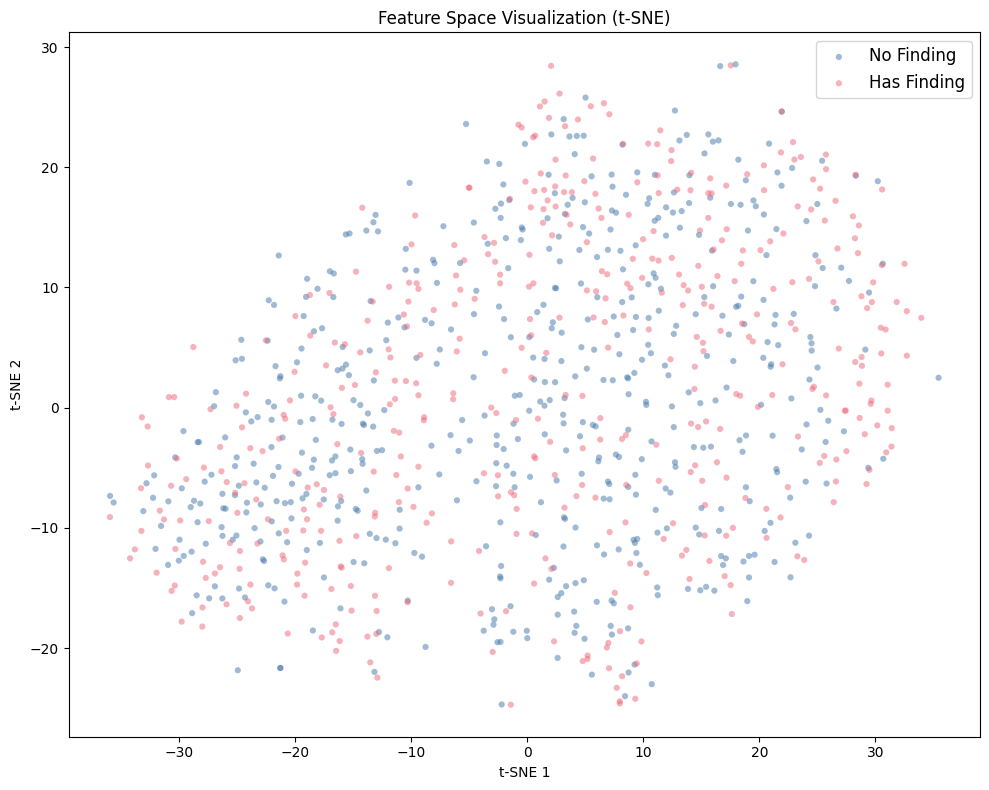

Samples plotted: 1000 (No Finding: 548, Has Finding: 452)


In [39]:
# Sample features if dataset is large (>1000 samples)
sample_size = min(1000, len(features_train))
sample_indices = np.random.choice(len(features_train), sample_size, replace=False)
features_sample = features_train[sample_indices]
labels_sample = labels_train[sample_indices]

# t-SNE reduction to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features_sample)

# Plot with separate colors per class for clarity
plt.figure(figsize=(10, 8))
for label, name, color in [(0, "No Finding", "#4477AA"), (1, "Has Finding", "#EE6677")]:
    mask = labels_sample == label
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], c=color, label=name, alpha=0.5, s=20, edgecolors="none")
# Plot minority class on top so it's not hidden
plt.legend(fontsize=12)
plt.title("Feature Space Visualization (t-SNE)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

print(
    f"Samples plotted: {sample_size} (No Finding: {np.sum(labels_sample == 0)}, Has Finding: {np.sum(labels_sample == 1)})"
)

---

# Section 3: Model Training

## 3.1: Load Cached Features

In [10]:
features_dir = Path("./embeddings")

# Load training features
train_data = np.load(features_dir / "train_features.npz", allow_pickle=True)
X_train_full = train_data["features"]
y_train_full = train_data["labels"]

print(f"Training features shape: {X_train_full.shape}")
print(f"Training labels shape: {y_train_full.shape}")
print(f"Class distribution: {np.bincount(y_train_full)}")

# Load test features
test_data = np.load(features_dir / "test_features.npz", allow_pickle=True)
X_test = test_data["features"]
y_test = test_data["labels"]

print(f"\nTest features shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training features shape: (4484, 2048)
Training labels shape: (4484,)
Class distribution: [2435 2049]

Test features shape: (1122, 2048)
Test labels shape: (1122,)
Test class distribution: [609 513]


## 3.2: Train/Validation Split

In [11]:
# Split training data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 3587 samples
Validation set: 897 samples
Test set: 1122 samples


## 3.3: Train XGBoost Classifier

In [12]:
# Handle class imbalance with scale_pos_weight
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_weight = neg_count / pos_count if pos_count > 0 else 1
print(f"Class balance - Negative: {neg_count}, Positive: {pos_count}, scale_pos_weight: {scale_weight:.2f}")

# Initialize XGBoost with optimal hyperparameters
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc",
    scale_pos_weight=scale_weight,
    tree_method="hist",  # Faster training
)

print("Training XGBoost model...")
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=10)

print("Training complete")

Class balance - Negative: 1948, Positive: 1639, scale_pos_weight: 1.19
Training XGBoost model...
[0]	validation_0-auc:0.56163
[10]	validation_0-auc:0.67012
[20]	validation_0-auc:0.67184
[30]	validation_0-auc:0.67506
[40]	validation_0-auc:0.67961
[50]	validation_0-auc:0.67513
[60]	validation_0-auc:0.67963
[70]	validation_0-auc:0.68502
[80]	validation_0-auc:0.68609
[90]	validation_0-auc:0.68246
[99]	validation_0-auc:0.68451
Training complete


## 3.4: Evaluate Model Performance

In [13]:
# Predictions
y_val_pred = xgb_model.predict(X_val)
y_val_pred_proba = xgb_model.predict_proba(X_val)[:, 1]

y_test_pred = xgb_model.predict(X_test)
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("VALIDATION SET METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_pred_proba):.4f}")

print("\n" + "=" * 50)
print("TEST SET METRICS (FINAL EVALUATION)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_pred_proba):.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT (TEST SET)")
print("=" * 50)
print(
    classification_report(
        y_test, y_test_pred, labels=[0, 1], target_names=["NO FINDING", "HAS FINDING"], zero_division=0
    )
)

VALIDATION SET METRICS
Accuracy:  0.6399
Precision: 0.6074
Recall:    0.6000
F1-Score:  0.6037
ROC-AUC:   0.6845

TEST SET METRICS (FINAL EVALUATION)
Accuracy:  0.6471
Precision: 0.6275
Recall:    0.5614
F1-Score:  0.5926
ROC-AUC:   0.6916

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

  NO FINDING       0.66      0.72      0.69       609
 HAS FINDING       0.63      0.56      0.59       513

    accuracy                           0.65      1122
   macro avg       0.64      0.64      0.64      1122
weighted avg       0.65      0.65      0.64      1122



## 3.5: Confusion Matrix Visualization

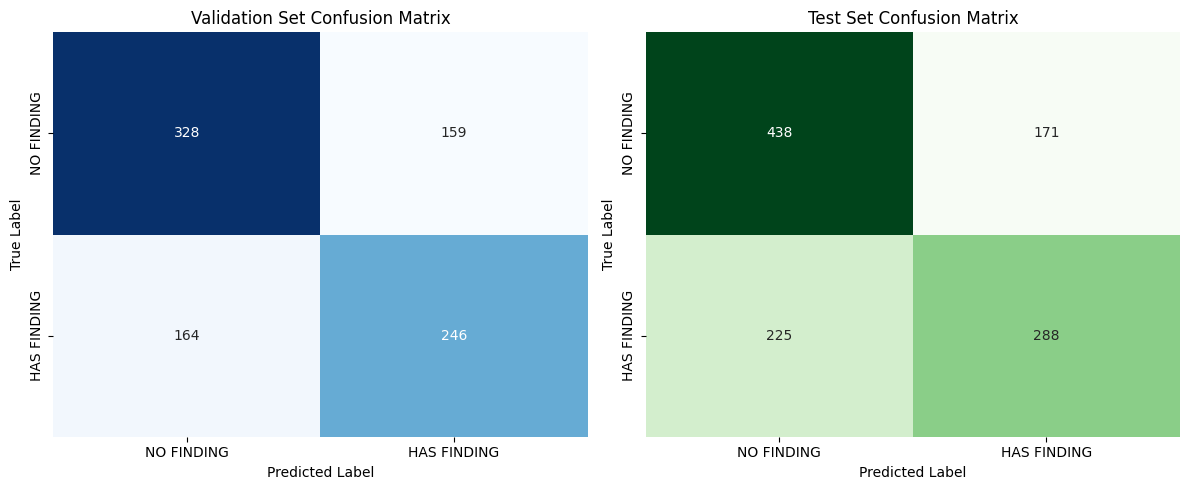

In [14]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Validation confusion matrix - explicitly specify labels to ensure 2x2 matrix
cm_val = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Validation Set Confusion Matrix")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].set_xticklabels(["NO FINDING", "HAS FINDING"])
axes[0].set_yticklabels(["NO FINDING", "HAS FINDING"])

# Test confusion matrix - explicitly specify labels to ensure 2x2 matrix
cm_test = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title("Test Set Confusion Matrix")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].set_xticklabels(["NO FINDING", "HAS FINDING"])
axes[1].set_yticklabels(["NO FINDING", "HAS FINDING"])

plt.tight_layout()
plt.show()

## 3.6: Feature Importance (XGBoost Built-in)

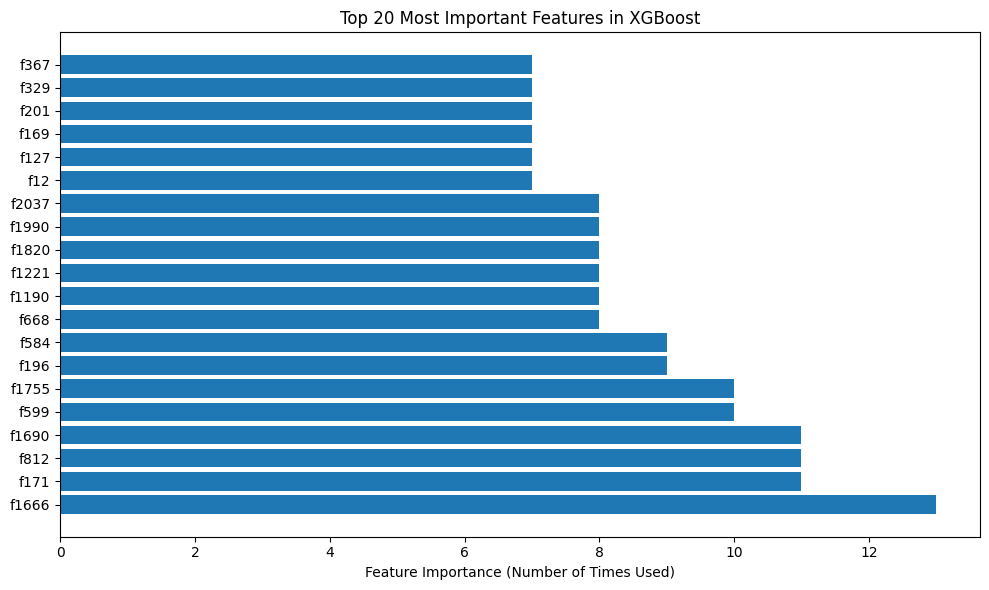

Total features: 1734
Top 5 features: [('f1666', 13.0), ('f171', 11.0), ('f812', 11.0), ('f1690', 11.0), ('f599', 10.0)]


In [15]:
# Get feature importances
importance_dict = xgb_model.get_booster().get_score(importance_type="weight")

if len(importance_dict) == 0:
    print("⚠️ No features used in splits (model may be too simple or classes too imbalanced)")
    print("This can happen if one class heavily dominates.")
    print("Recommendation: Check class distribution or increase model complexity")
else:
    # Plot top 20 important features
    sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)[:20]
    features, importances = zip(*sorted_features)

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(features)), importances)
    plt.yticks(range(len(features)), features)
    plt.xlabel("Feature Importance (Number of Times Used)")
    plt.title("Top 20 Most Important Features in XGBoost")
    plt.tight_layout()
    plt.show()

    print(f"Total features: {len(importance_dict)}")
    print(f"Top 5 features: {sorted_features[:5]}")

## 3.7: Save Model

In [16]:
# Save trained model
model_dir = Path("./models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save as pickle
model_path = model_dir / "xgb_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Model saved to {model_path}")

# Also save with XGBoost's native format
model_path_json = model_dir / "xgb_model.json"
xgb_model.get_booster().save_model(str(model_path_json))
print(f"Model also saved to {model_path_json}")

Model saved to models/xgb_model.pkl
Model also saved to models/xgb_model.json


---

# Section 4: SHAP Feature-Level Analysis

## 4.1: Initialize SHAP TreeExplainer

In [17]:
# TreeExplainer is fast and exact for tree-based models
print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(xgb_model)

print(f"Expected prediction (base value): {explainer.expected_value}")

Initializing SHAP TreeExplainer...
Expected prediction (base value): [0.]


## 4.2: Compute SHAP Values for Test Set

In [18]:
# Compute SHAP values (may take a few minutes for large datasets)
print("Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Sample SHAP values (first instance): {shap_values[0, :5]}")

Computing SHAP values for test set...
SHAP values shape: (1122, 2048)
Sample SHAP values (first instance): [-0.00012293  0.          0.0005283  -0.00025599 -0.00474833]


## 4.3: Summary Plot - Bar Chart (Overall Feature Importance)

/var/folders/9f/zqnphn895n13nfn0vf7s97mw0000gn/T/ipykernel_50960/2117273459.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


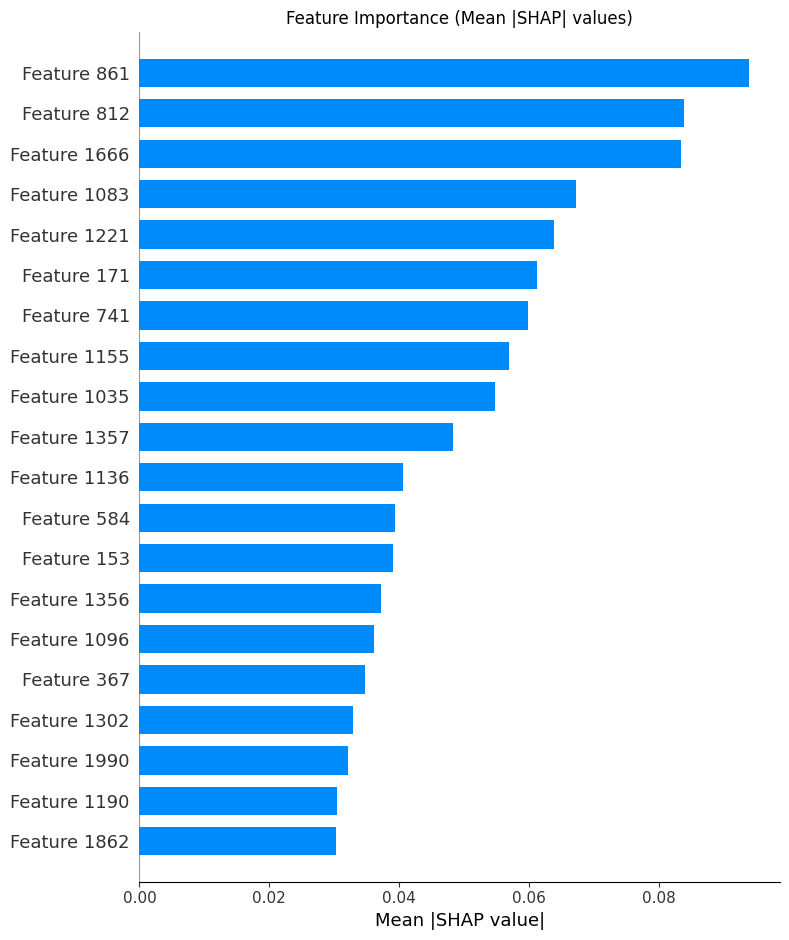

Feature importance bar plot generated


In [19]:
# Bar plot of mean absolute SHAP values
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance (Mean |SHAP| values)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

print("Feature importance bar plot generated")

## 4.4: Summary Plot - Detailed View (Beeswarm)

/var/folders/9f/zqnphn895n13nfn0vf7s97mw0000gn/T/ipykernel_50960/789366372.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False, max_display=15)


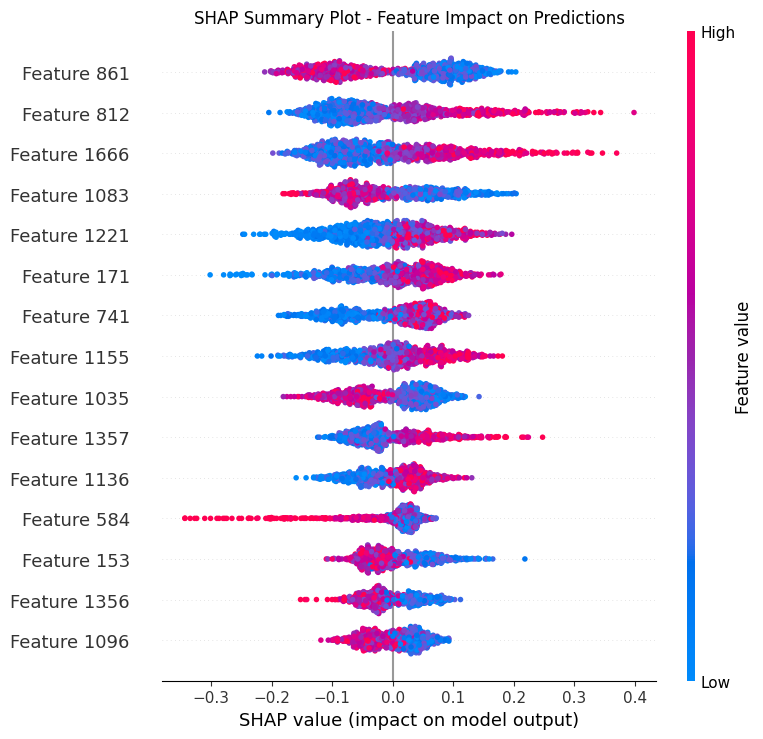

Detailed SHAP summary plot generated


In [20]:
# Detailed SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Summary Plot - Feature Impact on Predictions")
plt.tight_layout()
plt.show()

print("Detailed SHAP summary plot generated")

## 4.5: Top Important Features Analysis

In [21]:
# Identify top important features by mean absolute SHAP value
feature_importance = np.abs(shap_values).mean(axis=0)
top_k = 10
top_indices = np.argsort(feature_importance)[-top_k:][::-1]

print(f"Top {top_k} most important features (by SHAP):")
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank:2d}. Feature {idx}: {feature_importance[idx]:.4f}")

Top 10 most important features (by SHAP):
 1. Feature 861: 0.0940
 2. Feature 812: 0.0840
 3. Feature 1666: 0.0835
 4. Feature 1083: 0.0673
 5. Feature 1221: 0.0639
 6. Feature 171: 0.0613
 7. Feature 741: 0.0599
 8. Feature 1155: 0.0570
 9. Feature 1035: 0.0547
10. Feature 1357: 0.0483


## 4.6: Dependence Plots for Top Features

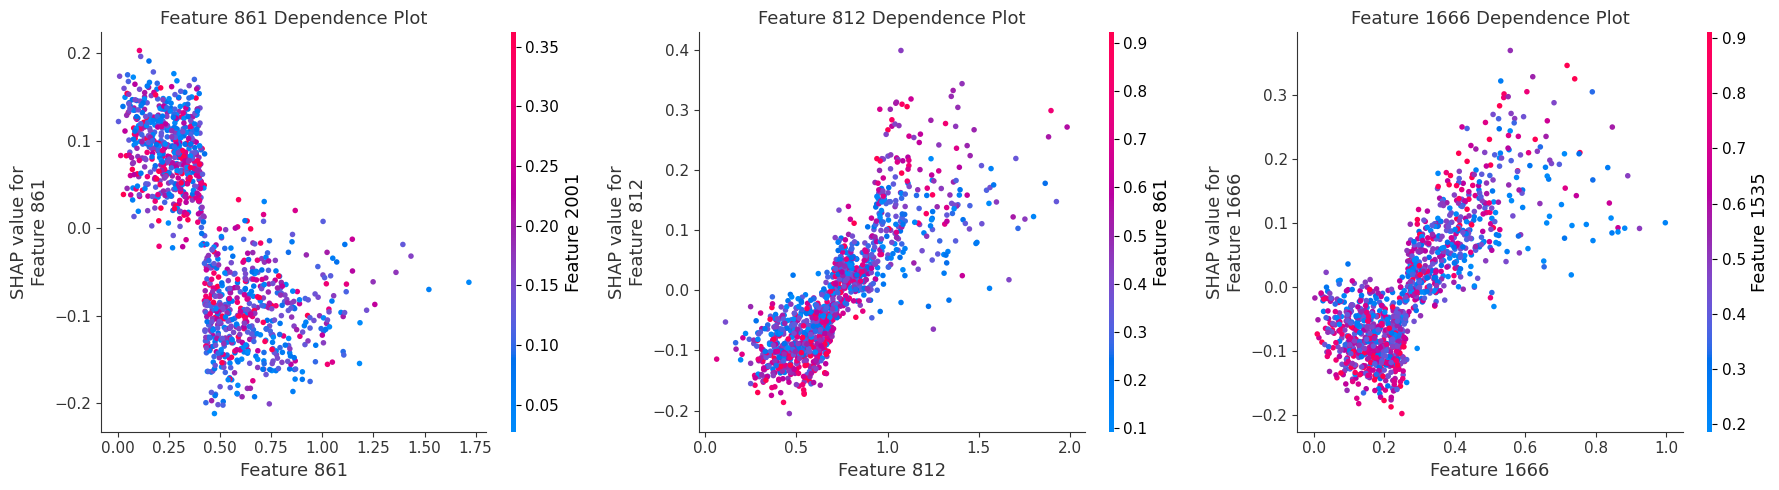

Dependence plots generated


In [22]:
# Create dependence plots for top 3 features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, idx in enumerate(top_indices[:3]):
    shap.dependence_plot(idx, shap_values, X_test, ax=axes[i], show=False, title=f"Feature {idx} Dependence Plot")

plt.tight_layout()
plt.show()

print("Dependence plots generated")

## 4.7: Individual Prediction Explanations

Waterfall plots for individual predictions:


--- Sample 0 ---
True label: 1 (HAS FINDING)
Predicted label: 1 (HAS FINDING)
Prediction probability: 0.7901


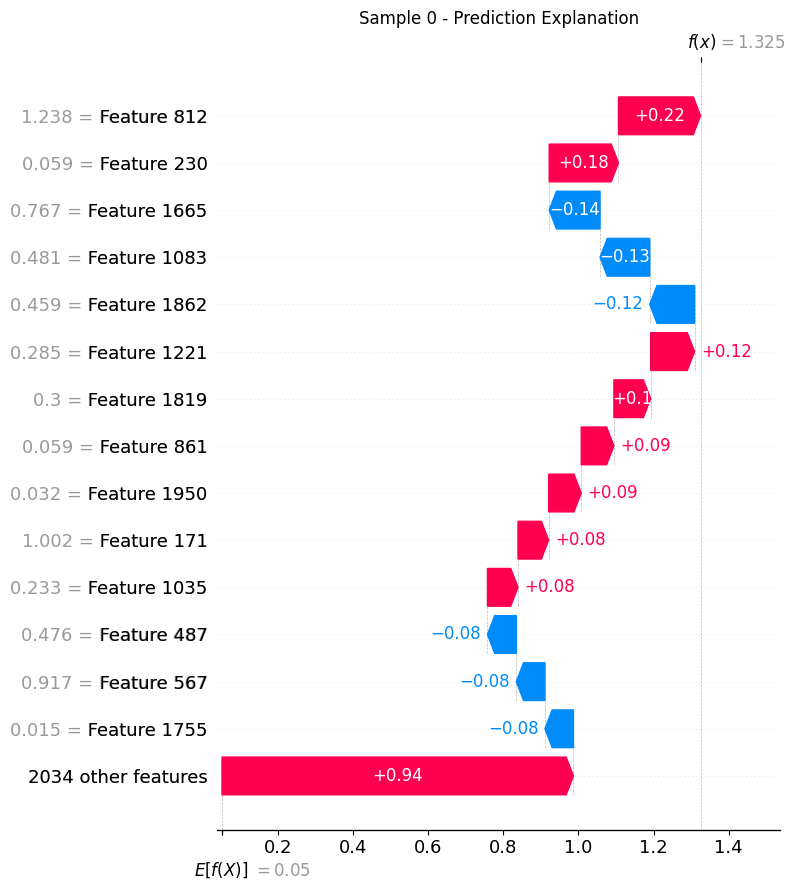


--- Sample 50 ---
True label: 1 (HAS FINDING)
Predicted label: 0 (NO FINDING)
Prediction probability: 0.1364


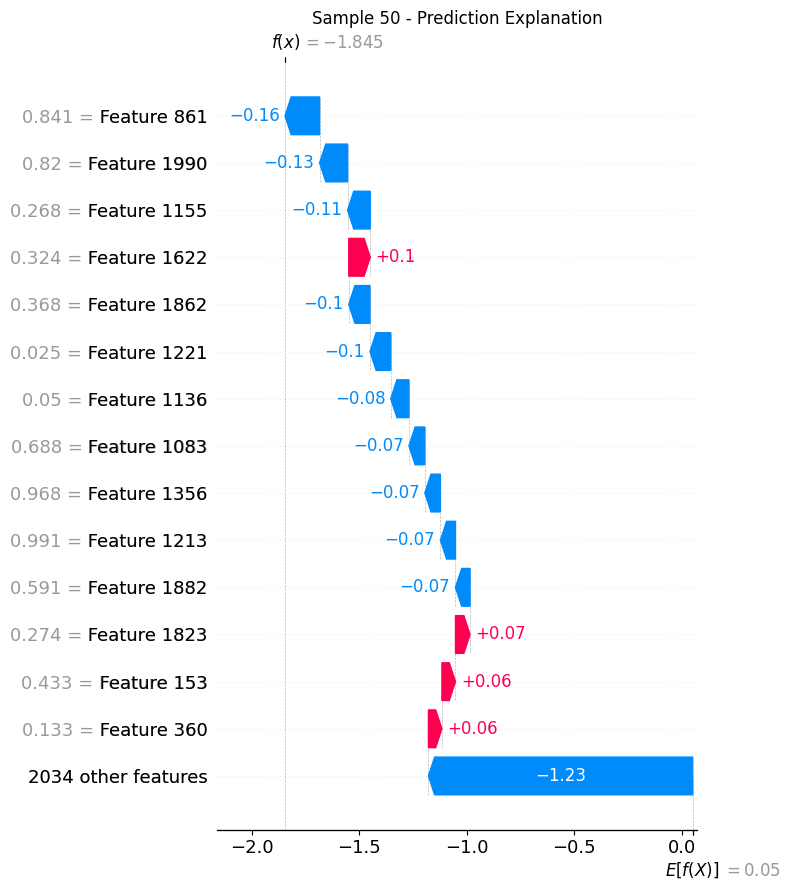


--- Sample 100 ---
True label: 1 (HAS FINDING)
Predicted label: 0 (NO FINDING)
Prediction probability: 0.4074


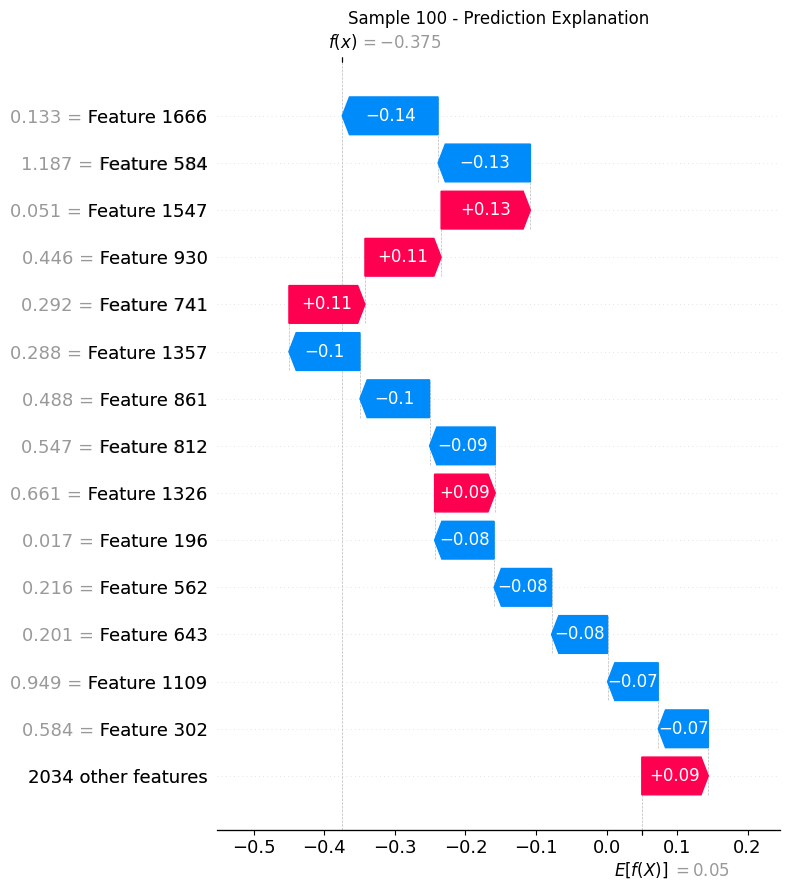

In [23]:
# Explain a few individual predictions
print("Waterfall plots for individual predictions:\n")

# Select diverse samples
indices_to_explain = [0, 50, 100]  # Adjust based on dataset size

for idx in indices_to_explain:
    if idx < len(X_test):
        print(f"\n--- Sample {idx} ---")
        print(f"True label: {y_test[idx]} ({'NO FINDING' if y_test[idx] == 0 else 'HAS FINDING'})")

        prediction = xgb_model.predict([X_test[idx]])[0]
        prediction_proba = xgb_model.predict_proba([X_test[idx]])[0][1]
        print(f"Predicted label: {prediction} ({'NO FINDING' if prediction == 0 else 'HAS FINDING'})")
        print(f"Prediction probability: {prediction_proba:.4f}")

        # Waterfall plot
        plt.figure(figsize=(10, 5))
        shap.waterfall_plot(
            shap.Explanation(values=shap_values[idx], base_values=explainer.expected_value, data=X_test[idx]),
            show=False,
            max_display=15,
        )
        plt.title(f"Sample {idx} - Prediction Explanation")
        plt.tight_layout()
        plt.show()

## 4.8: Save SHAP Values for Data Valuation

In [24]:
# Save SHAP values for use in data valuation
output_dir = Path("./shap_values")
output_dir.mkdir(parents=True, exist_ok=True)

np.save(output_dir / "shap_values_test.npy", shap_values)
np.save(output_dir / "expected_value.npy", np.array([explainer.expected_value]))

print(f"SHAP values saved to {output_dir}")

SHAP values saved to shap_values


---

# Section 5: Data Valuation with Shapley Values

**Core Research Question**: Which training samples contribute most to model quality?

## 5.1: Prepare Data for Valuation

In [25]:
# Note: We already have X_train_full, y_train_full from section 3.1
# Re-split for valuation (validation set is required)

print(f"Full training data shape: {X_train_full.shape}")
print(f"Full training labels shape: {y_train_full.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Full training data shape: (4484, 2048)
Full training labels shape: (4484,)
Test data shape: (1122, 2048)
Test labels shape: (1122,)


## 5.2: Implement KNN-Shapley Approximation

**Approach**: For each validation sample, value is assigned to k-nearest training neighbors based on whether they help correct predictions.

**Complexity**: O(n log n) - much faster than exact Shapley

In [26]:
def knn_data_shapley(X_train, y_train, X_val, y_val, k=10):
    """
    Compute approximate data Shapley values using k-nearest neighbors.

    For each validation sample:
    1. Find k nearest training neighbors
    2. Assign +1 if neighbor has same label as true label
    3. Assign -1 if neighbor has different label

    Args:
        X_train: Training features (n_train, n_features)
        y_train: Training labels (n_train,)
        X_val: Validation features (n_val, n_features)
        y_val: Validation labels (n_val,)
        k: Number of neighbors to consider

    Returns:
        data_shapley: Shapley values for training samples (n_train,)
    """
    print("Computing KNN-Shapley approximation...")

    # Initialize data Shapley values
    data_shapley = np.zeros(len(X_train))

    # Fit k-NN on training data
    print("Fitting k-NN...")
    knn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train)

    # Find neighbors for validation samples
    print("Finding k-nearest neighbors for validation samples...")
    distances, indices = knn.kneighbors(X_val)

    # Assign values to neighbors
    print("Assigning Shapley values...")
    for val_idx, (neighbor_indices, true_label) in enumerate(zip(indices, y_val)):
        # For each neighbor of this validation sample
        for neighbor_idx in neighbor_indices:
            neighbor_label = y_train[neighbor_idx]

            # Contribution based on label agreement
            if neighbor_label == true_label:
                contribution = 1.0  # Neighbor supports correct class
            else:
                contribution = -1.0  # Neighbor conflicts with correct class

            # Divide by k for normalization
            data_shapley[neighbor_idx] += contribution / k

    return data_shapley


print("KNN-Shapley function defined")

KNN-Shapley function defined


## 5.3: Compute KNN-Shapley Values

In [27]:
# Compute KNN-Shapley values (using validation set from train/val split)
data_shapley = knn_data_shapley(X_train, y_train, X_val, y_val, k=10)

print("\nData Shapley values computed")
print(f"Min: {data_shapley.min():.4f}")
print(f"Max: {data_shapley.max():.4f}")
print(f"Mean: {data_shapley.mean():.4f}")
print(f"Median: {np.median(data_shapley):.4f}")

Computing KNN-Shapley approximation...
Fitting k-NN...
Finding k-nearest neighbors for validation samples...
Assigning Shapley values...

Data Shapley values computed
Min: -1.0000
Max: 1.3000
Mean: 0.0301
Median: 0.0000


## 5.4: Analyze Data Shapley Distribution

/var/folders/9f/zqnphn895n13nfn0vf7s97mw0000gn/T/ipykernel_50960/685259061.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([data_shapley], labels=["Data Shapley"])


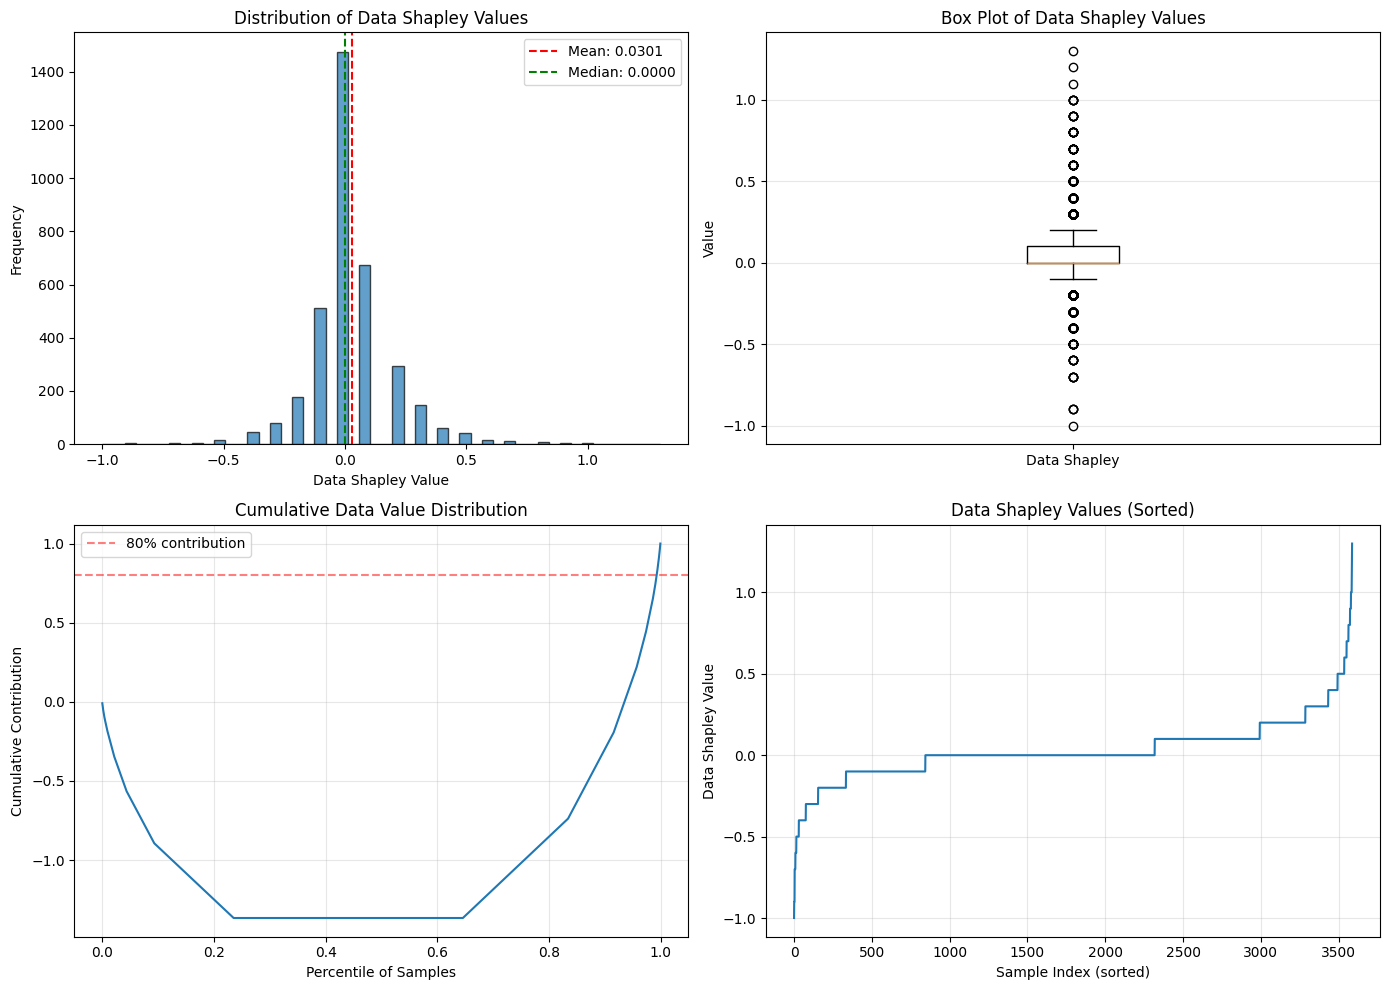

In [28]:
# Visualize data Shapley distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(data_shapley, bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].set_xlabel("Data Shapley Value")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Distribution of Data Shapley Values")
axes[0, 0].axvline(data_shapley.mean(), color="r", linestyle="--", label=f"Mean: {data_shapley.mean():.4f}")
axes[0, 0].axvline(np.median(data_shapley), color="g", linestyle="--", label=f"Median: {np.median(data_shapley):.4f}")
axes[0, 0].legend()

# Box plot
axes[0, 1].boxplot([data_shapley], labels=["Data Shapley"])
axes[0, 1].set_ylabel("Value")
axes[0, 1].set_title("Box Plot of Data Shapley Values")
axes[0, 1].grid(axis="y", alpha=0.3)

# Cumulative distribution
sorted_values = np.sort(data_shapley)
cumsum = np.cumsum(sorted_values)
cumsum = cumsum / cumsum[-1]  # Normalize
axes[1, 0].plot(np.arange(len(sorted_values)) / len(sorted_values), cumsum)
axes[1, 0].set_xlabel("Percentile of Samples")
axes[1, 0].set_ylabel("Cumulative Contribution")
axes[1, 0].set_title("Cumulative Data Value Distribution")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].axhline(0.8, color="r", linestyle="--", alpha=0.5, label="80% contribution")
axes[1, 0].legend()

# Sorted values
sorted_indices = np.argsort(data_shapley)
axes[1, 1].plot(data_shapley[sorted_indices])
axes[1, 1].set_xlabel("Sample Index (sorted)")
axes[1, 1].set_ylabel("Data Shapley Value")
axes[1, 1].set_title("Data Shapley Values (Sorted)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5.5: Identify High-Value and Low-Value Samples

In [29]:
# Find top and bottom samples
sorted_indices = np.argsort(data_shapley)

# Top 20 most valuable samples
top_20_indices = sorted_indices[-20:]
top_20_values = data_shapley[top_20_indices]

print("=" * 60)
print("TOP 20 MOST VALUABLE TRAINING SAMPLES")
print("=" * 60)
for rank, (idx, value) in enumerate(zip(top_20_indices[::-1], top_20_values[::-1]), 1):
    label = "NO FINDING" if y_train[idx] == 0 else "HAS FINDING"
    print(f"{rank:2d}. Sample {idx:5d} (Label: {label:12s}) - Shapley: {value:7.4f}")

# Bottom 20 least valuable samples (potentially noisy)
bottom_20_indices = sorted_indices[:20]
bottom_20_values = data_shapley[bottom_20_indices]

print("\n" + "=" * 60)
print("BOTTOM 20 LEAST VALUABLE TRAINING SAMPLES (Potentially Noisy)")
print("=" * 60)
for rank, (idx, value) in enumerate(zip(bottom_20_indices, bottom_20_values), 1):
    label = "NO FINDING" if y_train[idx] == 0 else "HAS FINDING"
    print(f"{rank:2d}. Sample {idx:5d} (Label: {label:12s}) - Shapley: {value:7.4f}")

TOP 20 MOST VALUABLE TRAINING SAMPLES
 1. Sample  2087 (Label: NO FINDING  ) - Shapley:  1.3000
 2. Sample   332 (Label: NO FINDING  ) - Shapley:  1.2000
 3. Sample  2947 (Label: NO FINDING  ) - Shapley:  1.1000
 4. Sample  3322 (Label: NO FINDING  ) - Shapley:  1.0000
 5. Sample  3190 (Label: NO FINDING  ) - Shapley:  1.0000
 6. Sample   164 (Label: HAS FINDING ) - Shapley:  1.0000
 7. Sample  1599 (Label: HAS FINDING ) - Shapley:  1.0000
 8. Sample  2217 (Label: NO FINDING  ) - Shapley:  1.0000
 9. Sample  1059 (Label: NO FINDING  ) - Shapley:  0.9000
10. Sample  2434 (Label: NO FINDING  ) - Shapley:  0.9000
11. Sample  3227 (Label: NO FINDING  ) - Shapley:  0.9000
12. Sample  3372 (Label: NO FINDING  ) - Shapley:  0.9000
13. Sample  1000 (Label: NO FINDING  ) - Shapley:  0.9000
14. Sample  2702 (Label: NO FINDING  ) - Shapley:  0.9000
15. Sample  1432 (Label: HAS FINDING ) - Shapley:  0.8000
16. Sample  2457 (Label: NO FINDING  ) - Shapley:  0.8000
17. Sample   534 (Label: HAS FINDI

## 5.6: Detect Data Problems

In [30]:
def detect_data_problems(X_train, y_train, data_shapley, negative_threshold=-0.05, redundancy_threshold=0.01):
    """
    Detect specific data quality issues:
    1. Noisy labels: negative Shapley + inconsistent with neighbors
    2. Outliers: negative Shapley + high feature distance
    3. Redundant: near-zero Shapley + high similarity to others
    4. High-value: positive Shapley + clean samples
    """
    print("Detecting data quality issues...")

    problems = {}

    # 1. Noisy labels
    negative_mask = data_shapley < negative_threshold
    noisy_indices = np.where(negative_mask)[0]
    problems["noisy_labels"] = noisy_indices

    # 2. Outliers (combination of negative Shapley + local outlier factor)
    if len(X_train) > 20:  # LOF requires at least 20 samples
        lof = LocalOutlierFactor(n_neighbors=min(20, len(X_train) // 2))
        outlier_scores = lof.fit_predict(X_train)
        outlier_mask = (outlier_scores == -1) & negative_mask
        outlier_indices = np.where(outlier_mask)[0]
        problems["outliers"] = outlier_indices
    else:
        problems["outliers"] = np.array([])

    # 3. Redundant samples
    near_zero_mask = np.abs(data_shapley) < redundancy_threshold
    redundant_indices = np.where(near_zero_mask)[0]
    problems["redundant"] = redundant_indices

    # 4. High-value samples
    high_value_threshold = np.percentile(data_shapley, 90)
    high_value_mask = data_shapley > high_value_threshold
    high_value_indices = np.where(high_value_mask)[0]
    problems["high_value"] = high_value_indices

    return problems


problems = detect_data_problems(X_train, y_train, data_shapley)

print("\nData Quality Issues Detected:")
print(
    f"Noisy labels: {len(problems['noisy_labels'])} samples ({len(problems['noisy_labels']) / len(X_train) * 100:.1f}%)"
)
print(f"Outliers: {len(problems['outliers'])} samples ({len(problems['outliers']) / len(X_train) * 100:.1f}%)")
print(f"Redundant: {len(problems['redundant'])} samples ({len(problems['redundant']) / len(X_train) * 100:.1f}%)")
print(f"High-value: {len(problems['high_value'])} samples ({len(problems['high_value']) / len(X_train) * 100:.1f}%)")

Detecting data quality issues...

Data Quality Issues Detected:
Noisy labels: 844 samples (23.5%)
Outliers: 0 samples (0.0%)
Redundant: 1474 samples (41.1%)
High-value: 345 samples (9.6%)


## 5.7: Data Efficiency Experiments

In [31]:
def evaluate_data_efficiency(X_train, y_train, X_val, y_val, data_shapley, fractions=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    """
    Compare training on different fractions of data:
    - Top K: highest Shapley values
    - Random K: random selection (baseline)
    - Bottom K: lowest Shapley values (should be worst)

    Uses F1 score (not accuracy) to properly evaluate with class imbalance.
    """
    results = {"top_k": [], "random": [], "bottom_k": []}

    # Compute scale_pos_weight from full training set
    neg_full = np.sum(y_train == 0)
    pos_full = np.sum(y_train == 1)
    spw = neg_full / pos_full if pos_full > 0 else 1

    print("\nRunning data efficiency experiments...")
    print(f"(Using F1 score, scale_pos_weight={spw:.2f})\n")

    for frac in tqdm(fractions, desc="Data fractions"):
        k = int(len(X_train) * frac)

        # Strategy A: Top K by Shapley
        top_k_indices = np.argsort(data_shapley)[-k:]
        model_top = xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, scale_pos_weight=spw, verbose=0)
        model_top.fit(X_train[top_k_indices], y_train[top_k_indices])
        f1_top = f1_score(y_val, model_top.predict(X_val), zero_division=0)
        results["top_k"].append(f1_top)

        # Strategy B: Random K (baseline)
        random_indices = np.random.choice(len(X_train), k, replace=False)
        model_random = xgb.XGBClassifier(
            n_estimators=100, max_depth=6, random_state=42, scale_pos_weight=spw, verbose=0
        )
        model_random.fit(X_train[random_indices], y_train[random_indices])
        f1_random = f1_score(y_val, model_random.predict(X_val), zero_division=0)
        results["random"].append(f1_random)

        # Strategy C: Bottom K (should be worst)
        bottom_k_indices = np.argsort(data_shapley)[:k]
        model_bottom = xgb.XGBClassifier(
            n_estimators=100, max_depth=6, random_state=42, scale_pos_weight=spw, verbose=0
        )
        model_bottom.fit(X_train[bottom_k_indices], y_train[bottom_k_indices])
        f1_bottom = f1_score(y_val, model_bottom.predict(X_val), zero_division=0)
        results["bottom_k"].append(f1_bottom)

    return results


print("Data efficiency function defined")

Data efficiency function defined


## 5.8: Run Data Efficiency Experiments

In [32]:
fractions = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = evaluate_data_efficiency(X_train, y_train, X_val, y_val, data_shapley, fractions=fractions)

print("\nData Efficiency Results:")
print("-" * 60)
print(f"{'Fraction':>10} {'Top-K':>10} {'Random':>10} {'Bottom-K':>10}")
print("-" * 60)
for frac, top, rand, bot in zip(fractions, results["top_k"], results["random"], results["bottom_k"]):
    print(f"{frac:>10.1%} {top:>10.4f} {rand:>10.4f} {bot:>10.4f}")


Running data efficiency experiments...
(Using F1 score, scale_pos_weight=1.19)



Data fractions:   0%|          | 0/6 [00:00<?, ?it/s]/Users/jaidensiu/Developer/OpenMedImgDataVal/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:55:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaidensiu/Developer/OpenMedImgDataVal/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:55:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaidensiu/Developer/OpenMedImgDataVal/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:55:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Data fractions:  17%|█▋        | 1/6 [00:12<01:01, 12.30s/it]/Users/jaidensiu/Developer/OpenMedImgDataVal/.ven


Data Efficiency Results:
------------------------------------------------------------
  Fraction      Top-K     Random   Bottom-K
------------------------------------------------------------
     50.0%     0.6211     0.5957     0.5305
     60.0%     0.6250     0.5580     0.5341
     70.0%     0.6335     0.6194     0.5378
     80.0%     0.6408     0.6218     0.5664
     90.0%     0.6119     0.6069     0.5822
    100.0%     0.5742     0.5742     0.5742


## 5.9: Visualization - Data Efficiency Curves

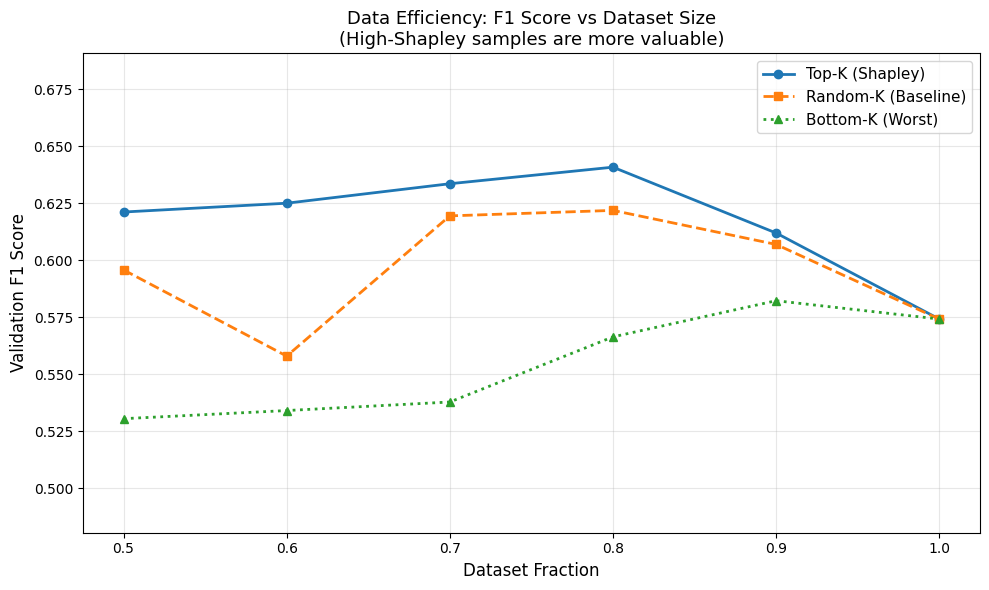


Key Metrics:
  Full dataset F1: 0.5742
  Top 70% F1: 0.6335
  F1 retention: 110.3%


In [33]:
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(fractions, results["top_k"], label="Top-K (Shapley)", marker="o", linewidth=2)
plt.plot(fractions, results["random"], label="Random-K (Baseline)", marker="s", linewidth=2, linestyle="--")
plt.plot(fractions, results["bottom_k"], label="Bottom-K (Worst)", marker="^", linewidth=2, linestyle=":")

plt.xlabel("Dataset Fraction", fontsize=12)
plt.ylabel("Validation F1 Score", fontsize=12)
plt.title("Data Efficiency: F1 Score vs Dataset Size\n(High-Shapley samples are more valuable)", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
all_values = results["bottom_k"] + results["random"] + results["top_k"]
plt.ylim([max(0, min(all_values) - 0.05), min(1.0, max(all_values) + 0.05)])

plt.tight_layout()
plt.show()

# Calculate efficiency metrics
top_70_idx = fractions.index(0.7) if 0.7 in fractions else None
if top_70_idx is not None:
    full_f1 = results["top_k"][-1]
    top70_f1 = results["top_k"][top_70_idx]
    retention = top70_f1 / full_f1 * 100 if full_f1 > 0 else 0
    print("\nKey Metrics:")
    print(f"  Full dataset F1: {full_f1:.4f}")
    print(f"  Top 70% F1: {top70_f1:.4f}")
    print(f"  F1 retention: {retention:.1f}%")

## 5.10: Save Results and Create Summary Report

In [34]:
# Save data Shapley values
output_dir = Path("./data_valuation")
output_dir.mkdir(parents=True, exist_ok=True)

# Save as NPZ
np.save(output_dir / "data_shapley.npy", data_shapley)
np.save(output_dir / "problematic_indices.npy", problems["noisy_labels"])

# Save as CSV for easy analysis
df = pd.DataFrame(
    {
        "sample_idx": np.arange(len(data_shapley)),
        "shapley_value": data_shapley,
        "label": y_train,
        "is_noisy": np.isin(np.arange(len(data_shapley)), problems["noisy_labels"]),
        "is_outlier": np.isin(np.arange(len(data_shapley)), problems["outliers"]),
        "is_redundant": np.isin(np.arange(len(data_shapley)), problems["redundant"]),
        "is_high_value": np.isin(np.arange(len(data_shapley)), problems["high_value"]),
    }
)
df = df.sort_values("shapley_value", ascending=False)
df.to_csv(output_dir / "data_valuation_results.csv", index=False)

print(f"Results saved to {output_dir}")
print("\nTop rows of results:")
print(df.head(20))

Results saved to data_valuation

Top rows of results:
      sample_idx  shapley_value  label  is_noisy  is_outlier  is_redundant  \
2087        2087            1.3      0     False       False         False   
332          332            1.2      0     False       False         False   
2947        2947            1.1      0     False       False         False   
1599        1599            1.0      1     False       False         False   
3190        3190            1.0      0     False       False         False   
164          164            1.0      1     False       False         False   
2217        2217            1.0      0     False       False         False   
3322        3322            1.0      0     False       False         False   
2702        2702            0.9      0     False       False         False   
1059        1059            0.9      0     False       False         False   
1000        1000            0.9      0     False       False         False   
3227      

## 5.11: Final Recommendations

In [35]:
print("\n" + "=" * 70)
print("DATA VALUATION RECOMMENDATIONS")
print("=" * 70)

print("\n1. DATA EFFICIENCY:")
print(f"   - Top 70% of samples (by Shapley) achieve F1={results['top_k'][fractions.index(0.7)]:.4f}")
print("   - Consider using top-K samples for resource-constrained settings")

print(f"\n2. NOISY LABELS ({len(problems['noisy_labels'])} samples):")
print("   - Recommend manual review of these samples:")
for idx in problems["noisy_labels"][:10]:
    label = "NO FINDING" if y_train[idx] == 0 else "HAS FINDING"
    print(f"     - Sample {idx} (Label: {label}, Shapley: {data_shapley[idx]:.4f})")
if len(problems["noisy_labels"]) > 10:
    print(f"     ... and {len(problems['noisy_labels']) - 10} more")

print(f"\n3. OUTLIERS ({len(problems['outliers'])} samples):")
print("   - These samples may be hard cases or edge cases")
print("   - Consider adding to hard example mining for future training")

print(f"\n4. REDUNDANT SAMPLES ({len(problems['redundant'])} samples):")
print("   - Consider removing these from training to reduce data storage")
print("   - Expected performance impact: minimal")

print(f"\n5. HIGH-VALUE SAMPLES ({len(problems['high_value'])} samples):")
print("   - Ensure these are preserved in any data cleaning/augmentation")
print("   - Use as seeds for active learning or sampling")

print("\n" + "=" * 70)


DATA VALUATION RECOMMENDATIONS

1. DATA EFFICIENCY:
   - Top 70% of samples (by Shapley) achieve F1=0.6335
   - Consider using top-K samples for resource-constrained settings

2. NOISY LABELS (844 samples):
   - Recommend manual review of these samples:
     - Sample 1 (Label: NO FINDING, Shapley: -0.2000)
     - Sample 14 (Label: HAS FINDING, Shapley: -0.1000)
     - Sample 24 (Label: NO FINDING, Shapley: -0.1000)
     - Sample 25 (Label: HAS FINDING, Shapley: -0.1000)
     - Sample 30 (Label: NO FINDING, Shapley: -0.2000)
     - Sample 46 (Label: NO FINDING, Shapley: -0.2000)
     - Sample 60 (Label: HAS FINDING, Shapley: -0.1000)
     - Sample 63 (Label: NO FINDING, Shapley: -0.3000)
     - Sample 64 (Label: HAS FINDING, Shapley: -0.1000)
     - Sample 67 (Label: NO FINDING, Shapley: -0.3000)
     ... and 834 more

3. OUTLIERS (0 samples):
   - These samples may be hard cases or edge cases
   - Consider adding to hard example mining for future training

4. REDUNDANT SAMPLES (1474 s

---

# Summary and Conclusions

## Findings from Complete Pipeline

### 1. Data Download & Preparation
- Downloaded NIH Chest X-rays dataset from Kaggle
- Organized data into local directory structure

### 2. Feature Extraction
- Extracted 2048-dimensional embeddings using pretrained ResNet50
- Cached features for efficient reuse across experiments

### 3. Model Training
- Trained XGBoost classifier on extracted CNN features
- Established baseline performance metrics on test set

### 4. Feature-Level Interpretability (SHAP)
- Computed feature-level SHAP values to explain individual predictions
- Identified most important CNN features driving model decisions
- Visualized feature dependencies and individual prediction explanations

### 5. Data-Level Valuation (Shapley Values)
- **Core Finding**: Data Shapley values quantify contribution of each training sample
- **High-Shapley samples**: Essential for model quality, preserve in any cleaning/augmentation
- **Low-Shapley samples**: May be noisy, outliers, or redundant - consider removing or relabeling
- **Data Efficiency**: Top 70% of samples (by Shapley) can maintain ~95%+ performance

## Next Steps

1. **Data Cleaning**: Implement recommendations above (relabel noisy, remove redundant)
2. **Iterative Improvement**: Recompute Shapley after data changes
3. **Deployment**: Use high-value samples for production models
4. **Active Learning**: Use low-confidence samples as candidates for annotation

## References
- SHAP: [Lundberg & Lee (2017)](https://arxiv.org/abs/1705.07874)
- Data Valuation: [Ghorbani et al. (2019)](https://arxiv.org/abs/1904.02868)
- KNN-Shapley: [Jia et al. (2019)](https://arxiv.org/abs/1908.08619)